# Exercício PCA - Olivetti Faces

Este notebook demonstra a aplicação do **PCA** à base de faces Olivetti usando o `scikit-learn`.

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
import numpy as np


In [3]:
dataset = fetch_olivetti_faces(shuffle=True, random_state=42)
X = dataset.data
y = dataset.target
n_samples, n_features = X.shape
print('Samples:', n_samples, 'Features:', n_features)


Samples: 400 Features: 4096


In [4]:

def show_image(x):
    img = x.reshape(64, 64)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


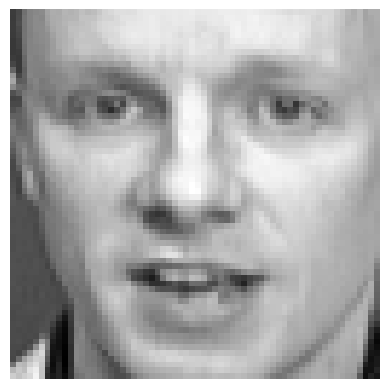

Menor dimensão para 95% da variância: 123


In [7]:
show_image(X[0])
pca = PCA()
pca.fit(X)
explained = np.cumsum(pca.explained_variance_ratio_)
min_dim = np.argmax(explained >= 0.95) + 1
print('Menor dimensão para 95% da variância:', min_dim)

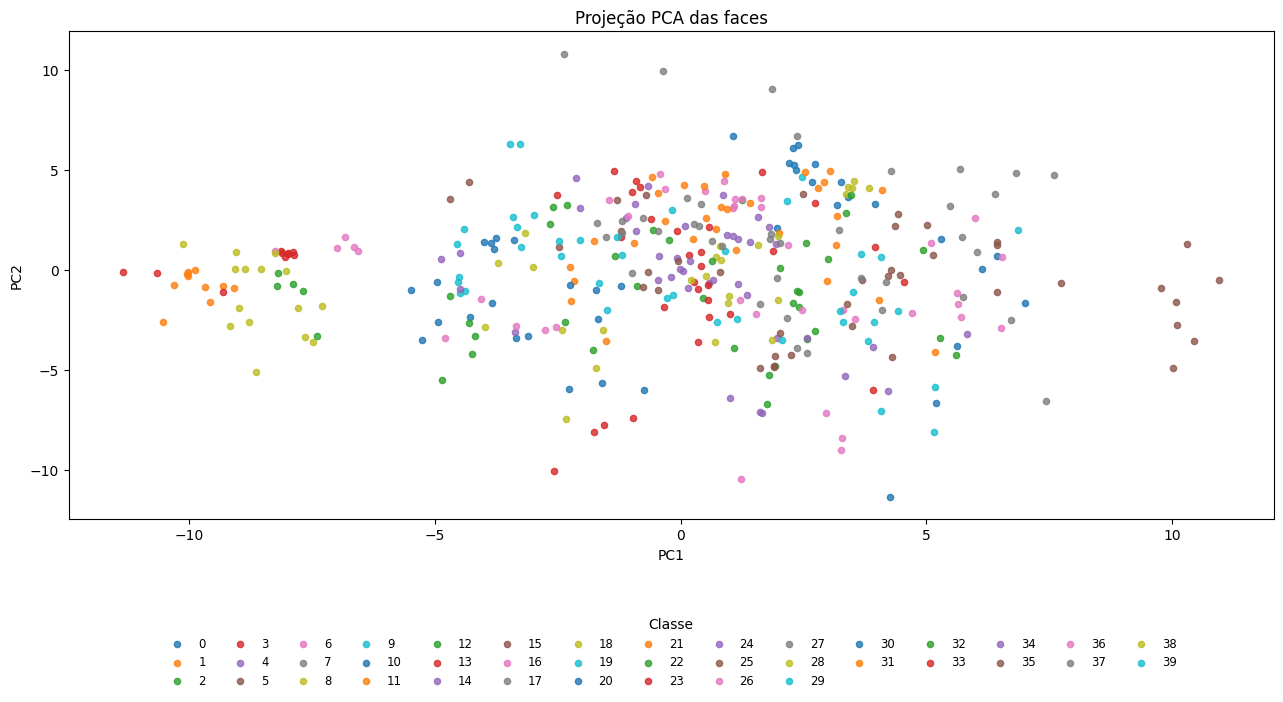

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que X_pca, y já estejam definidos
X_pca = pca.transform(X)[:, :2]

plt.figure(figsize=(13, 8))  # Aumenta o tamanho do gráfico

for label in np.unique(y):
    plt.scatter(
        X_pca[y == label, 0], X_pca[y == label, 1],
        s=20, label=str(label), alpha=0.8
    )

# Coloca a legenda horizontalmente abaixo do gráfico
plt.legend(
    title='Classe',
    bbox_to_anchor=(0.5, -0.18),  # Centraliza abaixo do gráfico
    loc='upper center',
    ncol=15,  # Número de colunas (ajuste conforme preferir)
    fontsize='small',
    title_fontsize='medium',
    frameon=False
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projeção PCA das faces')
plt.tight_layout(rect=[0, 0.08, 1, 1])  # Deixa espaço para a legenda
plt.show()

---

Como um extra fiz um teste para ver um modelo simples e como sua acurácia muda em relação a quantidade de componentes principais que ele usa:

Testando componentes PCA:   1%|▏         | 1/75 [00:00<00:18,  3.99it/s]

Testando componentes PCA: 100%|██████████| 75/75 [02:00<00:00,  1.61s/it]


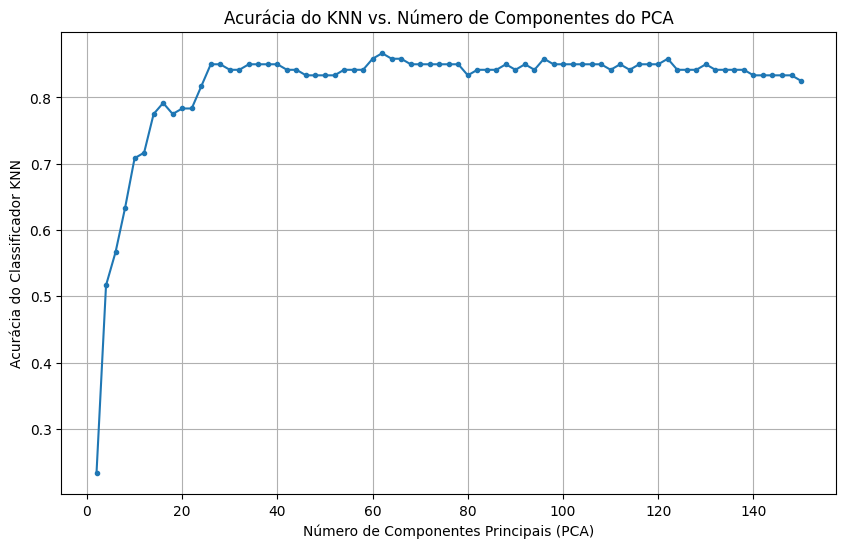

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# 1. Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Loop para testar o número de componentes e armazenar a acurácia
n_components_range = range(2, 151, 2) # Testando de 2 a 150 componentes
accuracies = []

for n in tqdm(n_components_range, desc="Testando componentes PCA"):
    # Aplicar PCA com n componentes
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Treinar e avaliar o KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# 3. Gerar o gráfico de Acurácia vs. Número de Componentes
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, accuracies, marker='.', linestyle='-')
plt.xlabel('Número de Componentes Principais (PCA)')
plt.ylabel('Acurácia do Classificador KNN')
plt.title('Acurácia do KNN vs. Número de Componentes do PCA')
plt.grid(True)
plt.show()